In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

tipe data: <class 'numpy.ndarray'>
shape    : (500, 700, 3)
dtype   : uint8

artinya: 
Tinggi = 500 piksel
lebar = 700 piksel
channel = 3 piksel
total pixel:  350000


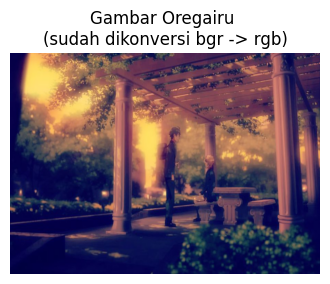

In [15]:
# Baca gambar dari file
#cv2.imread() mengembalikan array numpy !
img_bgr = cv2.imread('/content/drive/MyDrive/oregairu.jpg')

# Check if the image was loaded successfully
if img_bgr is None:
    print("Error: Could not load image. Please ensure 'oregairu.jpg' is in the correct directory.")
else:
    #resize agar tidak terlalu besar
    img_bgr = cv2.resize(img_bgr, (700, 500))

    #cek tipe data
    print("tipe data:", type(img_bgr))
    print("shape    :", img_bgr.shape)
    print("dtype   :", img_bgr.dtype)

    print()
    print("artinya: ")
    print(f"Tinggi = {img_bgr.shape[0]} piksel")
    print(f"lebar = {img_bgr.shape[1]} piksel")
    print(f"channel = {img_bgr.shape[2]} piksel")

    #konversi bgr -> rgb untuk ditampilkan di matplotlib
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    print("total pixel: ", img_rgb.shape[0] * img_rgb.shape[1])

    #tampilkan gambar
    plt.figure(figsize=(4,6))
    plt.imshow(img_rgb)
    plt.title('Gambar Oregairu \n(sudah dikonversi bgr -> rgb)')
    plt.axis('off')
    plt.show()

=== matriks f(x,y) - area 8x8 piksel ===
setiap angka = nilai intensitas 1 piksel (0=hitam, 255=putih)

[[106 104 104 102 103 108 113 116]
 [105 104 105 105 109 116 121 124]
 [106 105 108 110 115 123 127 129]
 [109 109 112 115 120 127 128 130]
 [112 112 116 118 122 128 126 128]
 [114 114 116 118 123 127 124 124]
 [115 113 114 118 121 122 120 119]
 [114 112 113 115 116 116 114 114]]

CONTOH baca: f(180, 200) = 131
CONTOH baca: f(181, 201) = 129
CONTOH baca: f(181, 201) = [167 118  89]
total pixel:  350000
total Size Kb:  342
total Size MB:  0.33


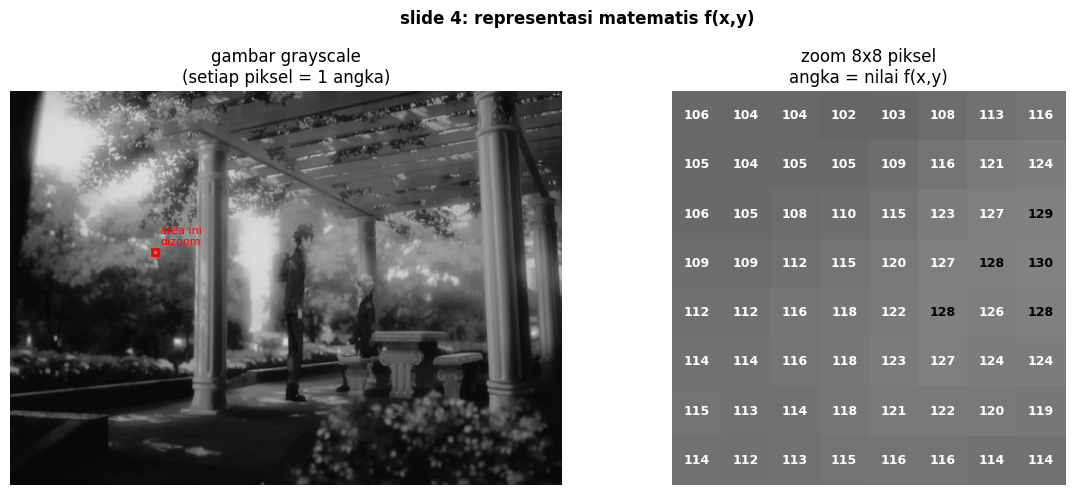

In [17]:
import matplotlib.patches as patches

img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

#Ambil area kecil
area_kecil = img_gray[200:208, 100:108]

print("=== matriks f(x,y) - area 8x8 piksel ===")
print("setiap angka = nilai intensitas 1 piksel (0=hitam, 255=putih)")
print()
print(area_kecil)
print()
print("CONTOH baca:" , f"f(180, 200) = {img_gray[200,180]}")
print("CONTOH baca:" , f"f(181, 201) = {img_gray[201,181]}")
print("CONTOH baca:" , f"f(181, 201) = {img_rgb[201,181]}")

total_pixel_gray = img_gray.shape[0] * img_gray.shape[1]
konversi_kb_gray = (total_pixel_gray*1)/1024
konversi_mb_gray = konversi_kb_gray/1024

print("total pixel: ", total_pixel_gray)
print("total Size Kb: ", round(konversi_kb_gray))
print("total Size MB: ", round(konversi_mb_gray, 2))


fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('gambar grayscale\n(setiap piksel = 1 angka)')
axes[0].axis('off')
rect=patches.Rectangle((180,200),8 ,8, linewidth=2, edgecolor='red', facecolor='none')
axes[0].add_patch(rect)
axes[0].text(190, 195, 'area ini\ndizoom', color='red', fontsize=8)

axes[1].imshow(area_kecil, cmap='gray', vmin=0, vmax=255)
for i in range(8):
  for j in range(8):
    nilai = area_kecil[i,j]
    warna_teks = 'white' if nilai < 128 else 'black'
    axes[1].text(j, i, str(nilai), ha='center', va='center',
                 fontsize=9, color=warna_teks, fontweight='bold')
axes[1].set_title('zoom 8x8 piksel\nangka = nilai f(x,y)')
axes[1].axis('off')
plt.suptitle('slide 4: representasi matematis f(x,y)', fontweight='bold')
plt.tight_layout()
plt.show()

=== matriks f(x,y) - area 8x8 piksel ===

Row 0: [132, 97, 87], [131, 94, 84], [131, 95, 83], [130, 92, 79], [133, 93, 78], [140, 97, 81], [145, 102, 86], [149, 105, 89]
Row 1: [131, 96, 86], [130, 94, 83], [132, 95, 83], [134, 95, 80], [140, 98, 81], [149, 105, 87], [154, 110, 91], [158, 112, 94]
Row 2: [132, 97, 86], [132, 96, 84], [136, 98, 84], [140, 99, 84], [147, 104, 86], [157, 112, 93], [161, 116, 95], [164, 118, 98]
Row 3: [135, 100, 89], [135, 100, 88], [140, 102, 88], [146, 104, 88], [153, 109, 90], [162, 116, 96], [164, 116, 95], [166, 118, 97]
Row 4: [138, 103, 91], [139, 103, 90], [144, 106, 90], [149, 107, 90], [155, 111, 92], [163, 117, 97], [162, 115, 92], [163, 116, 94]
Row 5: [140, 106, 91], [140, 105, 90], [144, 107, 90], [149, 108, 91], [154, 112, 94], [160, 117, 96], [157, 114, 92], [156, 114, 92]
Row 6: [140, 107, 90], [140, 104, 88], [141, 105, 87], [146, 109, 90], [150, 111, 93], [152, 113, 93], [150, 111, 92], [147, 110, 91]
Row 7: [138, 106, 89], [138, 104, 8

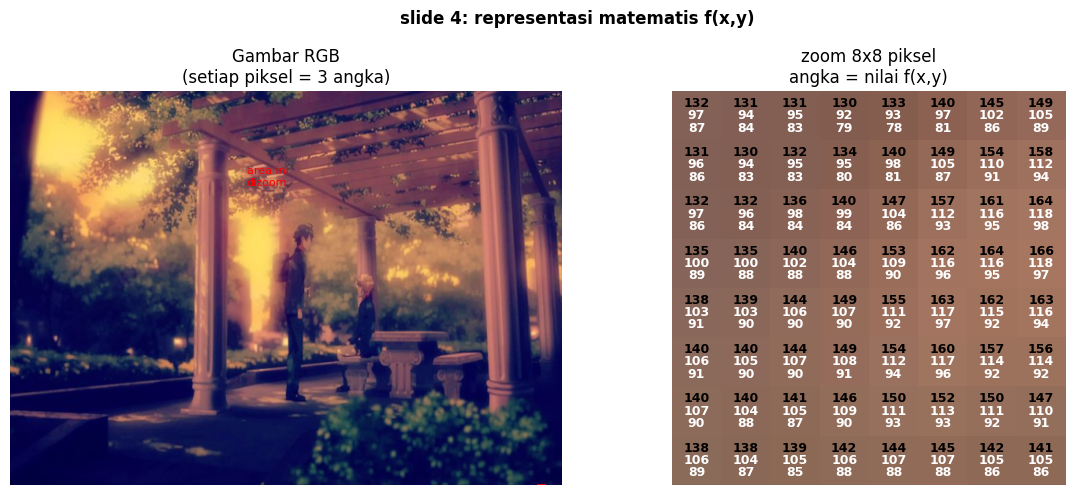

In [20]:
import matplotlib.patches as patches

#Ambil area kecil
area_kecil_rgb = img_rgb[200:208, 100:108]

print("=== matriks f(x,y) - area 8x8 piksel ===")
print()

for row_index, row in enumerate(area_kecil_rgb):
    row_str = []
    for pixel in row:
        row_str.append(f"[{pixel[0]}, {pixel[1]}, {pixel[2]}]")
    print(f"Row {row_index}: {', '.join(row_str)}")

print()
print("CONTOH baca:" , f"f(210, 190) = {img_rgb[210,190]}")
print("CONTOH baca:" , f"f(211, 191) = {img_rgb[211,191]}")

total_pixel = img_rgb.shape[0] * img_rgb.shape[1]
konversi_kb = (total_pixel*3)/1024
konversi_mb = konversi_kb/1024

print("total pixel: ", total_pixel)
print("total Size Kb: ", round(konversi_kb))
print("total Size MB: ", round(konversi_mb, 2))

fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].imshow(img_rgb, vmin=0, vmax=255)
axes[0].set_title('Gambar RGB\n(setiap piksel = 3 angka)')
axes[0].axis('off')
rect=patches.Rectangle((670,500),8 ,8, linewidth=2, edgecolor='red', facecolor='none')
axes[0].add_patch(rect)
axes[0].text(300, 120, 'area ini\ndizoom', color='red', fontsize=8)

def tentukan_warna(skor):
  match skor:
      case r if r < 125:
        return 'white'
      case _:
        return 'black'

axes[1].imshow(area_kecil_rgb)
for i in range(8):
  for j in range(8):
    nilai_rgb = area_kecil_rgb[i,j]
    offsets = [-0.25, 0 ,0.25]
    for mn in range(3):
      nilai_rgb_satuan = nilai_rgb[mn]
      hasil_cek = tentukan_warna(nilai_rgb_satuan)
      axes[1].text(j, i + offsets[mn], str(nilai_rgb_satuan), ha='center', va='center',fontsize=9, color=hasil_cek, fontweight='bold')

axes[1].set_title('zoom 8x8 piksel\nangka = nilai f(x,y)')
axes[1].axis('off')
plt.suptitle('slide 4: representasi matematis f(x,y)', fontweight='bold')
plt.tight_layout()
plt.show()